In [97]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf


In [ ]:
df=pd.read_csv(r'INPUT.csv')
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year
df=df.drop(columns=['DateTime','Valeur','Date'])
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df=df.fillna(0)
Y=df['MA']
X=df[[col for col in df.columns if col!='MA']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale only X
Y=pd.DataFrame(Y)
Y['MA_diff']=Y['MA'].diff()
Y=Y.fillna(0)

### Tests sur la série

stationarity

In [101]:
sm.tsa.stattools.adfuller(Y['MA_diff'], maxlag=None, regression='c', autolag='AIC', store=False, regresults=False)

(-35.42932278378242,
 0.0,
 44,
 17499,
 {'1%': -3.430723750472268,
  '5%': -2.8617051832726124,
  '10%': -2.5668579227683557},
 205717.15422110923)

homoscesdacticty

In [102]:
sm.stats.diagnostic.het_arch(Y['MA_diff'],nlags=None, store=False, ddof=0)

(2695.1484160311343, 0.0, 318.26644688012976, 0.0)

Autocorrelation

In [103]:
sm.stats.diagnostic.acorr_ljungbox(Y['MA_diff'].dropna(), lags=10, return_df=True)


,lb_stat,lb_pvalue
1,815.962813,1.826000e-179
2,1227.504855,2.822978e-267
3,1293.371592,4.037052e-280
4,1293.435859,8.817750e-279
5,1315.770494,2.447070e-282
6,1328.022914,9.292179e-284
7,1344.954585,3.133687e-286
8,1349.348972,5.054264e-286
9,1356.384104,2.047708e-286
10,1362.996459,9.666737e-287


Jacques Bera test for normality

In [104]:
sm.stats.stattools.jarque_bera(Y['MA_diff'].dropna())

(47379813.309629835, 0.0, -1.5558457099056857, 257.5690151286146)

In [105]:
# import pandas as pd
# from statsmodels.tsa.stattools import adfuller

# def test_stationarity_df(df, alpha=0.05):
#     results = []
#     for col in df.columns:
#         series = df[col].dropna()
#         if series.nunique() <= 1:  # Ignore colonnes constantes
#             results.append({
#                 "Variable": col,
#                 "ADF Stat": None,
#                 "p-value": None,
#                 "Stationnaire": "Constante",
#                 "Critique 5%": None
#             })
#             continue
        
#         adf_stat, p_value, _, _, crit_values, _ = adfuller(series)
#         stationnaire = "Oui" if p_value < alpha else "Non"
#         results.append({
#             "Variable": col,
#             "ADF Stat": adf_stat,
#             "p-value": p_value,
#             "Stationnaire": stationnaire,
#             "Critique 5%": crit_values['5%']
#         })
#     return pd.DataFrame(results)

# # Test sur X
# stationarity_results = test_stationarity_df(X)
# print(stationarity_results)


In [106]:
X.columns

Index(['Heure', 'Minute', 'Jour', 'Mois', 'Annee', 'SPOT', 'BIOMASS',
       'FOSSIL_GAS', 'FOSSIL_HARD_COAL', 'FOSSIL_OIL', 'HYDRO_PUMPED_STORAGE',
       'HYDRO_RUN_OF_RIVER', 'HYDRO_WATER_RESERVOIR', 'NUCLEAR', 'SOLAR',
       'WASTE', 'WIND_ONSHORE', 'conso'],
      dtype='object')

In [107]:
X['Prod-Conso']=X['BIOMASS']+X['FOSSIL_GAS']+X['FOSSIL_HARD_COAL']+X['FOSSIL_OIL']+X['HYDRO_PUMPED_STORAGE']+X['HYDRO_RUN_OF_RIVER']+X['HYDRO_WATER_RESERVOIR']+X['NUCLEAR']+X['SOLAR']+X['WASTE']+X['WIND_ONSHORE']-X['conso']

In [108]:
X_filtered = X[[col for col in X.columns if col not in ['Heure', 'Minute', 'Jour', 'Mois', 'Annee']]]


In [109]:
X_filtered.diff()

,SPOT,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso,Prod-Conso
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200.0,-200.0
2,-3.37,0.0,15.0,0.5,14.5,-17.0,-27.5,-99.5,-1429.5,-112.5,-2.0,-121.0,-5800.0,4021.0
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,900.0,-900.0
4,-16.06,0.0,-26.5,0.0,-0.5,191.0,75.5,-138.5,-104.0,0.0,2.0,-184.0,1700.0,-1885.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2.08,0.5,-121.0,0.0,0.0,-270.0,-187.0,-241.5,-56.0,0.0,-1.5,55.0,0.0,-821.5
17540,-8.64,-0.5,19.0,0.0,0.0,-667.0,-324.0,-38.5,-303.0,0.0,-0.5,113.0,0.0,-1201.5
17541,-6.57,1.0,-116.0,0.0,-0.5,-637.5,-63.0,-453.0,79.0,0.0,-1.0,163.0,0.0,-1028.0
17542,-0.24,-1.0,72.0,0.0,0.0,104.5,-53.5,-4.5,250.0,0.0,1.0,122.5,0.0,491.0


In [110]:
stationarity_results = test_stationarity_df(X_filtered.diff())
print(stationarity_results)

                 Variable   ADF Stat  p-value Stationnaire  Critique 5%
0                    SPOT -46.314840      0.0          Oui    -2.861705
1                 BIOMASS -90.790921      0.0          Oui    -2.861705
2              FOSSIL_GAS -32.348477      0.0          Oui    -2.861705
3        FOSSIL_HARD_COAL -22.290266      0.0          Oui    -2.861705
4              FOSSIL_OIL -34.083672      0.0          Oui    -2.861705
5    HYDRO_PUMPED_STORAGE -54.107032      0.0          Oui    -2.861705
6      HYDRO_RUN_OF_RIVER -42.474949      0.0          Oui    -2.861705
7   HYDRO_WATER_RESERVOIR -50.182997      0.0          Oui    -2.861705
8                 NUCLEAR -23.553393      0.0          Oui    -2.861705
9                   SOLAR -49.622586      0.0          Oui    -2.861705
10                  WASTE -28.829670      0.0          Oui    -2.861705
11           WIND_ONSHORE -24.629487      0.0          Oui    -2.861705
12                  conso -42.603329      0.0          Oui    -2

ACF/PACF

In [111]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

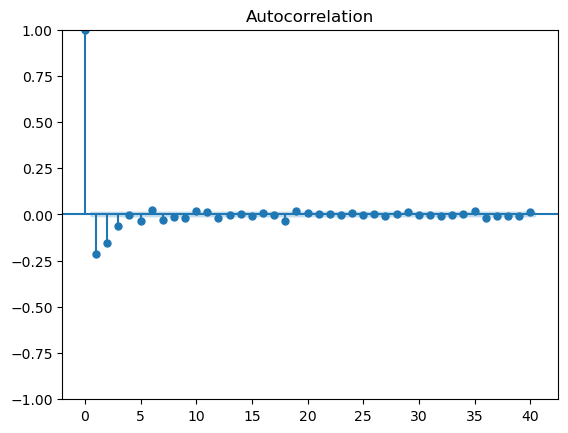

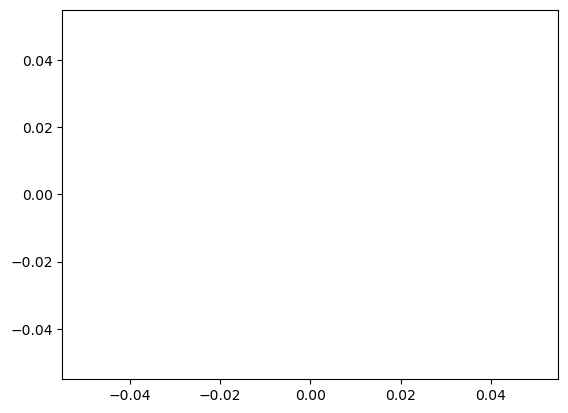

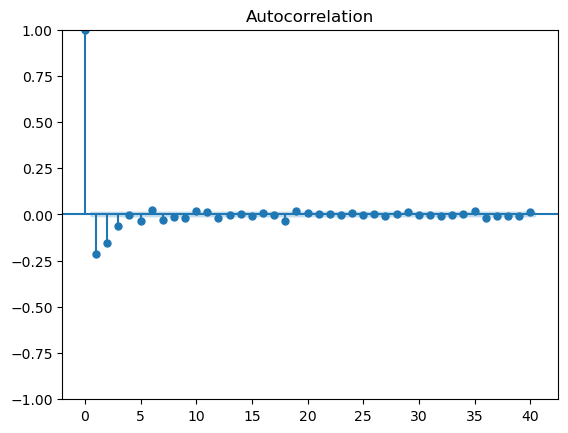

In [112]:
# ACF
plt.plot(figsize=(15,10))
plot_acf(Y['MA_diff'], ax=None, lags=40, alpha=0.05, use_vlines=True, adjusted=False, fft=False, missing='none', title='Autocorrelation', zero=True, auto_ylims=False, bartlett_confint=True, vlines_kwargs=None)

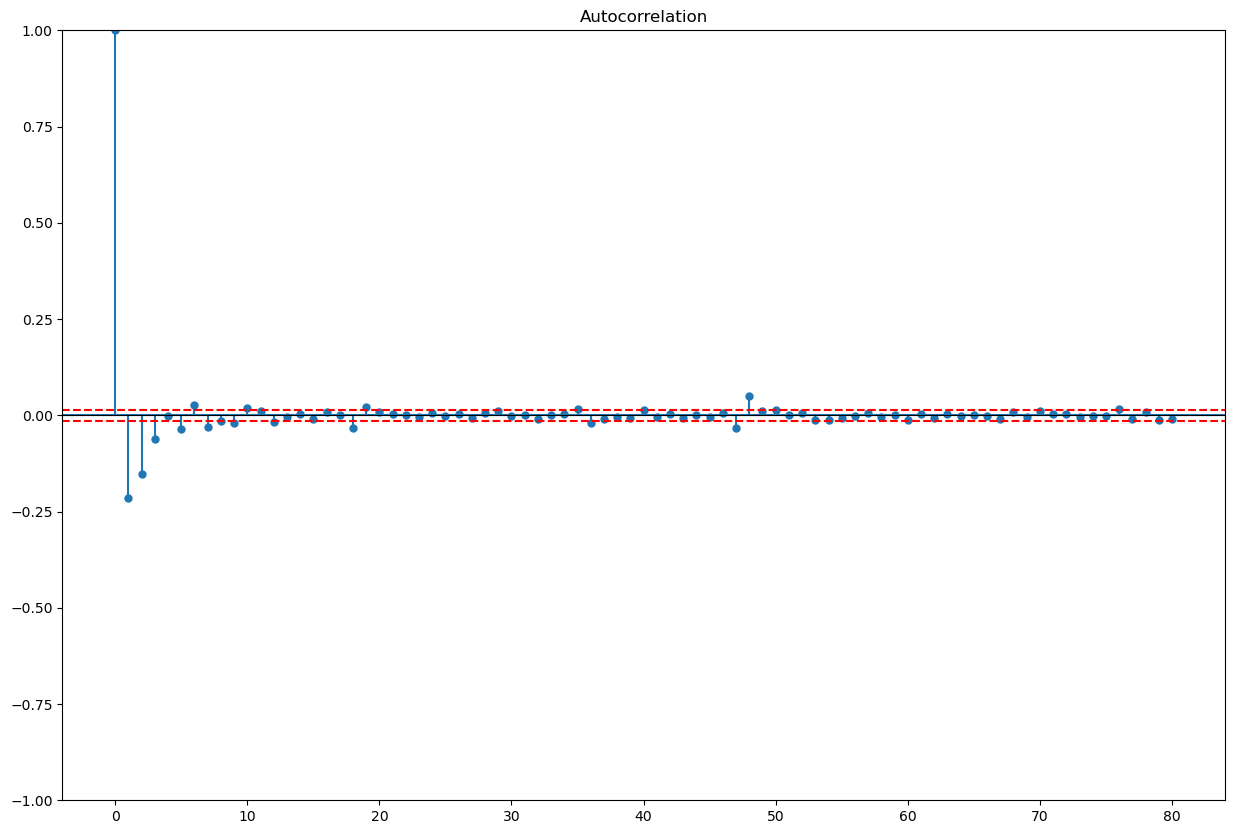

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

series = Y['MA_diff'].dropna()

fig, ax = plt.subplots(figsize=(15,10))
plot_acf(series, lags=80, alpha=None, ax=ax)

# seuil 95%
conf = 1.96 / np.sqrt(len(series))
ax.axhline(y=conf, color='red', linestyle='--')
ax.axhline(y=-conf, color='red', linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.8)

plt.show()


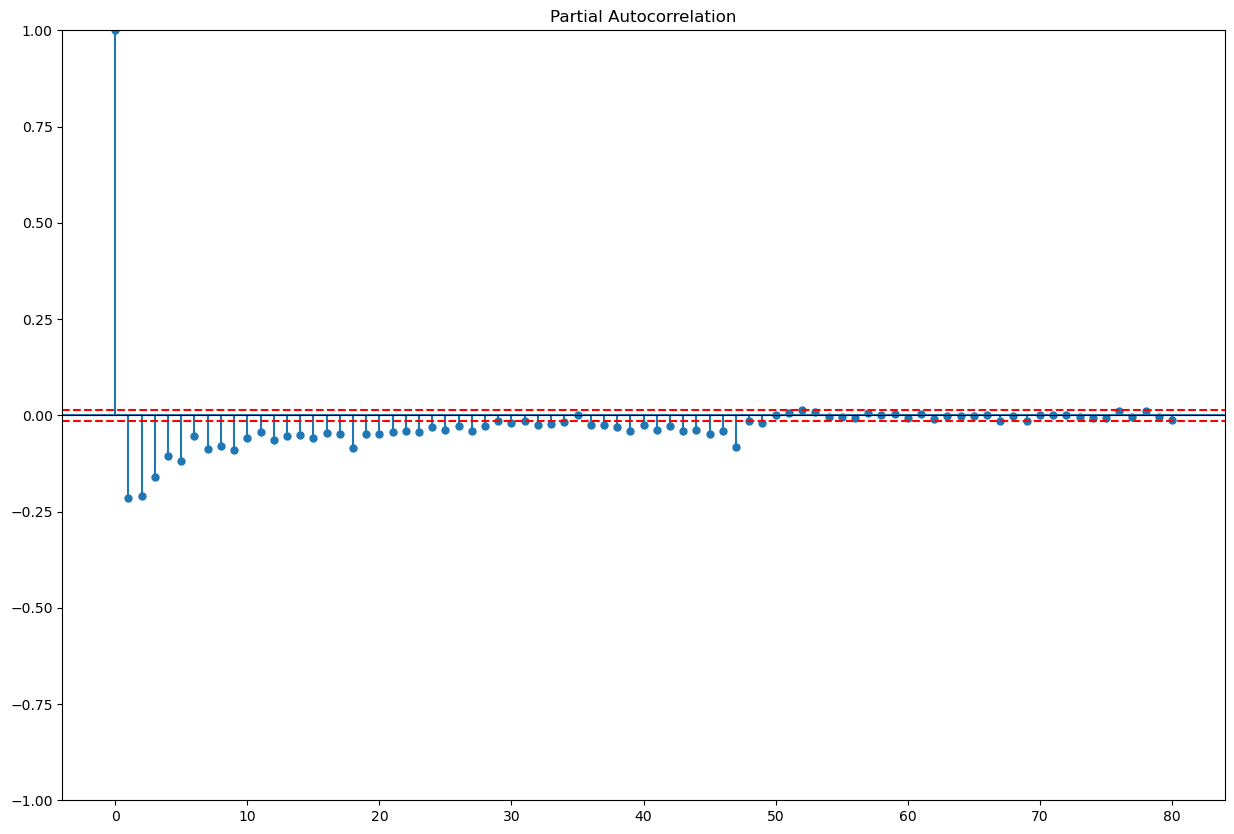

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

series = Y['MA_diff'].dropna()

fig, ax = plt.subplots(figsize=(15,10))
plot_pacf(series, lags=80, alpha=None, ax=ax)

# seuil 95%
conf = 1.96 / np.sqrt(len(series))
ax.axhline(y=conf, color='red', linestyle='--')
ax.axhline(y=-conf, color='red', linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.8)

plt.show()


information criteria

In [115]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(Y['MA'], order=(7,1,1),seasonal_order=(1,0,1,48))
results = model.fit()

results.info_criteria('bic', method='standard')


206076.53815153413

In [116]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Test de Ljung-Box sur les résidus du modèle
ljung_res = acorr_ljungbox(results.resid, lags=[10], boxpierce=False, model_df=0, period=None, return_df=True)

print(ljung_res)

      lb_stat  lb_pvalue
10  15.580584   0.112285


In [117]:
# from statsmodels.tsa.arima.model import ARIMA

# BIC_values = []
# AIC_values = []
# HQIC_values = []
# orders = []

# for p in range(0, 10):
#     for q in range(0, 3):
#         model = ARIMA(Y['MA'], order=(p, 1, q))
#         results = model.fit()
#         BIC_values.append(results.info_criteria('bic'))
#         AIC_values.append(results.info_criteria('aic'))
#         HQIC_values.append(results.info_criteria('hqic'))
#         orders.append((p, 1, q))

# bic_df = pd.DataFrame({
#     'order ARIMA': orders,
#     'AIC': AIC_values,
#     'BIC': BIC_values,
#     'HQIC': HQIC_values
# })


In [118]:
model = ARIMA(Y['MA'], order=(4,1,2))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                     MA   No. Observations:                17544
Model:                 ARIMA(4, 1, 2)   Log Likelihood             -103124.340
Date:              jeu., 14 août 2025   AIC                         206262.681
Time:                        16:37:21   BIC                         206317.088
Sample:                             0   HQIC                        206280.595
                              - 17544                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1618      0.043     -3.752      0.000      -0.246      -0.077
ar.L2          0.4096      0.025     16.586      0.000       0.361       0.458
ar.L3          0.0182      0.003      6.598      0.000       0.013       0.024
ar.L4          0.0657      0.003     19.246      0.000       0.059       0.072
ma.L1         -0.2499      0.043     -5.777      0.000      -0.335      -0.165
ma.L2         -0.7325      0.043    -17.170      0.000      -0.816      -0.649
sigma2      7472.0329      7.540    990.955      0.000    7457.254    7486.811
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):          43436117.70
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.45   Skew:                             3.44
Prob(H) (two-sided):                  0.00   Kurtosis:                       246.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [119]:
from statsmodels.tsa.stattools import adfuller
adfuller(results.resid, maxlag=None)  

(-22.44402845350382,
 0.0,
 28,
 17515,
 {'1%': -3.4307234090001404,
  '5%': -2.861705032364612,
  '10%': -2.566857842442296},
 205657.93074423185)

In [120]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Test de Ljung-Box sur les résidus du modèle
ljung_res = acorr_ljungbox(results.resid, lags=None, boxpierce=False, model_df=0, period=None, return_df=True)

print(ljung_res)


      lb_stat  lb_pvalue
1    0.001073   0.973865
2    0.040804   0.979805
3    0.067626   0.995417
4    0.708153   0.950320
5    2.002659   0.848777
6   11.741080   0.068001
7   13.018651   0.071655
8   17.150962   0.028575
9   18.199205   0.032931
10  21.019953   0.020955


In [121]:
sm.stats.diagnostic.het_arch(results.resid, nlags=None, store=False, ddof=0)

(3066.2561522064116, 0.0, 371.37792264207843, 0.0)

In [122]:
sm.stats.stattools.jarque_bera(results.resid, axis=0)

(43359561.86447575, 0.0, 3.435428507623332, 246.45060573190202)

In [263]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
ypred=results.fittedvalues
Y['MA_ARIMA']=ypred.shift(-1)
Y['MA_ARIMA'] = Y['MA_ARIMA'].fillna(Y['MA_ARIMA'].mean())
Y.head()
r2=r2_score(Y['MA'],Y['MA_ARIMA'])
mae=mean_absolute_error(Y['MA'],Y['MA_ARIMA'])
mse=mean_squared_error(Y['MA'],Y['MA_ARIMA'])
print(r2,mae,mse)

0.8333131070084565 23.682451789410944 2090.784037987333


SARIMA

In [125]:
# from statsmodels.tsa.arima.model import ARIMA

# BIC_values = []
# AIC_values = []
# HQIC_values = []
# orders = []
# S=[20,24,48]

# for s in S:
#     model = ARIMA(Y['MA'], order=(7,1,1),seasonal_order=(1,0,1,s))
#     results = model.fit()
#     BIC_values.append(results.info_criteria('bic'))
#     AIC_values.append(results.info_criteria('aic'))
#     HQIC_values.append(results.info_criteria('hqic'))
#     orders.append((1, 0, 1,s))

# bic_df_sa = pd.DataFrame({
#     'order SARIMA': orders,
#     'AIC': AIC_values,
#     'BIC': BIC_values,
#     'HQIC': HQIC_values
# })


In [126]:
# bic_df_sa

In [265]:
df=pd.read_csv(r'INPUT.csv')
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year
df=df.drop(columns=['DateTime','Valeur','Date'])
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df=df.fillna(0)
Y=df['MA']
X=df[[col for col in df.columns if col!='MA']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale only X
Y=pd.DataFrame(Y)
Y['MA_diff']=Y['MA'].diff()
Y=Y.fillna(0)

In [266]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera
from arch import arch_model

# 1️⃣ Fit du SARIMA
sarima_model = SARIMAX(
    Y['MA'],
    order=(7,1,1),
    seasonal_order=(1,0,1,48),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_res = sarima_model.fit(disp=False)
print(sarima_res.summary())

# Résidus du SARIMA
resid = sarima_res.resid.dropna()

# 2️⃣ Tests sur les résidus
# ADF
adf_stat, adf_p, _, _, crit_vals, _ = adfuller(resid)
print("\nADF Statistic:", adf_stat)
print("ADF p-value  :", adf_p)
print("ADF Crit Values:", crit_vals)



# ARCH test
arch_stat = het_arch(resid)
print("\nARCH LM Stat:", arch_stat[0], "p-value:", arch_stat[1])

# Jarque–Bera


# 3️⃣ GARCH sur les résidus
garch_model = arch_model(
    resid,
    vol='Garch',
    p=1, q=1,
    dist='t'  # Student-t pour queues lourdes
)
garch_res = garch_model.fit(update_freq=10, disp='off')
print("\n=== GARCH(1,1) Results ===")
print(garch_res.summary())

# 4️⃣ Diagnostic GARCH
std_resid = garch_res.std_resid.dropna()

print("\nTest ARCH sur résidus standardisés du GARCH :")
arch_stat_std = het_arch(std_resid)
print("ARCH LM Stat:", arch_stat_std[0], "p-value:", arch_stat_std[1])


                                     SARIMAX Results                                      
Dep. Variable:                                 MA   No. Observations:                17544
Model:             SARIMAX(7, 1, 1)x(1, 0, 1, 48)   Log Likelihood             -102681.414
Date:                          jeu., 14 août 2025   AIC                         205384.827
Time:                                    19:52:13   BIC                         205470.289
Sample:                                         0   HQIC                        205412.971
                                          - 17544                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5776      0.002    312.385      0.000       0.574       0.581
ar.L2         -0.0504      0.003   

###RefaireModele

In [267]:
fitted_sarima=sarima_res.fittedvalues[1:]
cond_var=garch_res.conditional_volatility
std_resid = garch_res.std_resid
fitted_resid = cond_var * std_resid
fitted_global = fitted_sarima + fitted_resid

In [268]:
Y['SARIMA_GARCH']=fitted_global.iloc[1:]

In [269]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
Y['SARIMA_GARCH']=Y['SARIMA_GARCH'].fillna(Y['SARIMA_GARCH'].mean())
mse=mean_squared_error(Y['MA'],Y['SARIMA_GARCH'])
mae=mean_absolute_error(Y['MA'],Y['SARIMA_GARCH'])
r2=r2_score(Y['MA'],Y['SARIMA_GARCH'])

In [270]:
r2,mse,mae

(0.9979365700865053, 25.881976976194085, 5.022077700975017)

### Model in and out

In [229]:
n=len(Y)
m=0.1
ytrain=Y['MA'].iloc[0:int(m*n)]
ytest=Y['MA'].iloc[int(m*n):int(m*n)+48]

sarima_model = SARIMAX(
    ytrain,
    order=(7,1,1),
    seasonal_order=(1,0,1,48),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_res = sarima_model.fit(disp=False)
yforecast=sarima_res.forecast(steps=48)

resid_train = sarima_res.resid.dropna()

garch_res = arch_model(
    resid_train, vol='GARCH', p=1, q=1, dist='t', mean='constant'
).fit(disp='off')

var_fore = garch_res.forecast(horizon=48, reindex=False).variance.values[-1]  # shape (48,)
sigma_fore = np.sqrt(var_fore)

rng = np.random.default_rng(123)                     # seed pour reproductibilité
z_pool = garch_res.std_resid.dropna().values        # innovations standardisées (~i.i.d., Var≈1)
z_boot = rng.choice(z_pool, size=48, replace=True)  # bootstrap local simple
rng = np.random.default_rng(123)                     # seed pour reproductibilité

yforecast_boot = yforecast.values + sigma_fore * z_boot





r2=r2_score(yforecast_boot,ytest,)
mae=mean_absolute_error(yforecast_boot,ytest)
mse=mean_squared_error(yforecast_boot,ytest)
r2_sarima=r2_score(ytest, yforecast)
r2,mae,mse,r2_sarima

NameError: name 'SARIMAX' is not defined

                                     SARIMAX Results                                      
Dep. Variable:                                 MA   No. Observations:                14035
Model:             SARIMAX(7, 1, 1)x(1, 0, 1, 48)   Log Likelihood              -83316.744
Date:                          jeu., 14 août 2025   AIC                         166655.487
Time:                                    20:18:48   BIC                         166738.485
Sample:                                         0   HQIC                        166683.120
                                          - 14035                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5741      0.002    272.592      0.000       0.570       0.578
ar.L2         -0.0440      0.003   

(-4.705049684760778, 40.714243837108604, 2416.011103570421)

boostrap

In [309]:
# n=len(Y)
# n=100
c1=[]
c2=[]
c3=[]
c4=[]
c5=[]
M=[100,1000,1900,2100,6000,4000,5000,4500,8500,10500]
for m in M:
    y=(Y['MA'].iloc[m:m+1000])
    WAGON=[24,48,50,75,100]
    windows=48
    # wagon=750
    n=3
    for wagon in WAGON:
        R=[]
        MAE=[]
        MSE=[]
        Mm=[]
        for i in range(wagon+windows,wagon+windows+n):
            ytest=y[i:i+windows]
            ytrain=y[i-windows-wagon:i]
            
            sarima_model = SARIMAX(
            ytrain,
            order=(7,1,1),
            seasonal_order=(1,0,1,48),
            enforce_stationarity=False,
            enforce_invertibility=False
            )
            sarima_res = sarima_model.fit(disp=False)
            yforecast=sarima_res.forecast(steps=windows)
            
            resid_train = sarima_res.resid.dropna()
            garch_res = arch_model(
            resid_train, vol='GARCH', p=1, q=1, dist='t', mean='constant'
            ).fit(disp='off')

            var_fore = garch_res.forecast(horizon=48, reindex=False).variance.values[-1]  # shape (48,)
            sigma_fore = np.sqrt(var_fore)

            rng = np.random.default_rng(123)                     # seed pour reproductibilité
            z_pool = garch_res.std_resid.dropna().values        # innovations standardisées (~i.i.d., Var≈1)
            z_boot = rng.choice(z_pool, size=48, replace=True)  # bootstrap local simple

            yforecast_boot = yforecast + sigma_fore * z_boot


            
            r2=round(r2_score(ytest,yforecast_boot),3)
            mae=round(mean_absolute_error(ytest,yforecast_boot))
            mse=round(mean_squared_error(ytest,yforecast_boot))

            # print(m,wagon,r2,mae,mse)
            R.append(r2)
            MAE.append(mae)
            MSE.append(mse)
            Mm.append(m)
        print(m,wagon,np.average(R), np.average(MAE), np.average(MSE))
        c1.append(m)
        c2.append(wagon)
        c3.append(np.average(R))
        c4.append(np.average(MAE))
        c5.append(np.average(MSE))
results = pd.DataFrame({
    'm': c1,
    'wagon': c2,
    'R2': c3,m
    'MAE': c4,
    'MSE': c5
})



100 24 -58.38766666666667 268.3333333333333 230517.66666666666
100 48 -12.807333333333332 165.33333333333334 77940.0
100 50 -11.733000000000002 151.66666666666666 70866.33333333333
100 75 -3.1786666666666665 133.33333333333334 33236.0
100 100 -2.991226652399201e+26 1051169807511658.6 2.8438018824369865e+30
1000 24 -8.200000000000001 117.33333333333333 23272.0
1000 48 -5.3486666666666665 91.33333333333333 14107.0
1000 50 -2.2773333333333334 66.66666666666667 7318.666666666667
1000 75 -6.876 85.33333333333333 11885.0
1000 100 -8.161797430452076e+27 2287294929899972.0 1.619063717803943e+31
1900 24 -3.7953333333333332 124.66666666666667 31162.333333333332
1900 48 -17.628 178.66666666666666 67959.0
1900 50 -27.077333333333332 198.33333333333334 79052.66666666667
1900 75 -10.832999999999998 146.0 38810.666666666664
1900 100 -7.844250421532045e+22 3107922099833.3335 1.647548378916884e+26
2100 24 -3.152333333333333 107.66666666666667 27697.0
2100 48 -1.703 110.0 22732.666666666668
2100 50 -2.9

In [311]:
results

,m,wagon,R2,MAE,MSE
0,100,24,-5.838767e+01,2.683333e+02,2.305177e+05
1,100,48,-1.280733e+01,1.653333e+02,7.794000e+04
2,100,50,-1.173300e+01,1.516667e+02,7.086633e+04
3,100,75,-3.178667e+00,1.333333e+02,3.323600e+04
4,100,100,-2.991227e+26,1.051170e+15,2.843802e+30
5,1000,24,-8.200000e+00,1.173333e+02,2.327200e+04
6,1000,48,-5.348667e+00,9.133333e+01,1.410700e+04
7,1000,50,-2.277333e+00,6.666667e+01,7.318667e+03
8,1000,75,-6.876000e+00,8.533333e+01,1.188500e+04
9,1000,100,-8.161797e+27,2.287295e+15,1.619064e+31


## VAR

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller



In [3]:
df=pd.read_csv(r'INPUT.csv')
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year
df=df.drop(columns=['DateTime','Valeur','Date'])
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df=df.fillna(0)
Y=df['MA']
X=df[[col for col in df.columns if col!='MA']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale only X
Y=pd.DataFrame(Y)
Y['MA_diff']=Y['MA'].diff()
Y=Y.fillna(0)

C:\Users\adamh\AppData\Local\Temp\ipykernel_10260\644945001.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'])


In [4]:
X['Prod-Conso']=X['BIOMASS']+X['FOSSIL_GAS']+X['FOSSIL_HARD_COAL']+X['FOSSIL_OIL']+X['HYDRO_PUMPED_STORAGE']+X['HYDRO_RUN_OF_RIVER']+X['HYDRO_WATER_RESERVOIR']+X['NUCLEAR']+X['SOLAR']+X['WASTE']+X['WIND_ONSHORE']-X['conso']
X_filtered = X[[col for col in X.columns if col not in ['Heure', 'Minute', 'Jour', 'Mois', 'Annee']]]
X=X.drop(columns=['Annee'])
Xdiff=X.diff()

In [5]:
def is_stationnary(X):
    PVALUE=[]
    C=[]
    St=[]
    for c in X.columns:
        PVALUE.append(adfuller(X[c], autolag="AIC")[1])
        C.append(c)
        St.append(adfuller(X[c], autolag="AIC")[1]<=0.05)
    return pd.DataFrame({'Exogenuous variable':C,'Pvalue':PVALUE,'Stationary':St })

In [6]:
is_stationnary(Xdiff.dropna())

,Exogenuous variable,Pvalue,Stationary
0,Heure,0.0,True
1,Minute,0.0,True
2,Jour,0.0,True
3,Mois,0.0,True
4,SPOT,0.0,True
5,BIOMASS,0.0,True
6,FOSSIL_GAS,0.0,True
7,FOSSIL_HARD_COAL,0.0,True
8,FOSSIL_OIL,0.0,True
9,HYDRO_PUMPED_STORAGE,0.0,True


In [7]:
source=['BIOMASS','FOSSIL_GAS','FOSSIL_HARD_COAL','FOSSIL_OIL','HYDRO_PUMPED_STORAGE','HYDRO_RUN_OF_RIVER','HYDRO_WATER_RESERVOIR','NUCLEAR','SOLAR','WASTE','WIND_ONSHORE','conso']
source2=['MA','SPOT','BIOMASS','FOSSIL_GAS','FOSSIL_HARD_COAL','FOSSIL_OIL','HYDRO_PUMPED_STORAGE','HYDRO_RUN_OF_RIVER','HYDRO_WATER_RESERVOIR','NUCLEAR','SOLAR','WASTE','WIND_ONSHORE','conso']

Xreduit=X.drop(columns='Prod-Conso')
Xreduit.head()

,Heure,Minute,Jour,Mois,SPOT,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso
0,0,0,1,1,19.49,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,52800.0
1,0,30,1,1,19.49,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,53000.0
2,1,0,1,1,16.12,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,47200.0
3,1,30,1,1,16.12,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,48100.0
4,2,0,1,1,0.06,171.5,893.5,8.0,95.0,-842.5,2459.0,502.5,18660.0,0.0,43.5,6894.5,49800.0


In [8]:
Xreduit['Heure_sin']=np.sin(2*np.pi*Xreduit['Heure']/24)
Xreduit['Heure_cos']=np.cos(2*np.pi*Xreduit['Heure']/24)
Xreduit['Minute_sin']=np.sin(2*np.pi*Xreduit['Minute']/60)
Xreduit['Minute_cos']=np.cos(2*np.pi*Xreduit['Minute']/60)
Xreduit=Xreduit.drop(columns=['Heure','Minute'])

In [9]:
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler().set_output(transform="pandas")
Xscaled_reduit=Xscaler.fit_transform(Xreduit)
Xscaled_reduit.head()

,Jour,Mois,SPOT,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso,Heure_sin,Heure_cos,Minute_sin,Minute_cos
0,-1.674641,-1.597089,-0.942618,-0.038028,-0.089212,-0.283558,-0.004085,-1.302513,-0.280012,-0.484189,0.136284,-0.634085,-1.608579,2.678594,0.396101,1.689657e-17,1.414214,-0.998633,0.998633
1,-1.674641,-1.597089,-0.942618,-0.038028,-0.089212,-0.283558,-0.004085,-1.302513,-0.280012,-0.484189,0.136284,-0.634085,-1.608579,2.678594,0.415401,1.689657e-17,1.414214,1.001369,-1.001369
2,-1.674641,-1.597089,-1.025522,-0.038028,-0.074077,-0.277371,0.230530,-1.322680,-0.325767,-0.693506,-0.138940,-0.697342,-1.665263,2.613266,-0.144311,3.660254e-01,1.366025,-0.998633,0.998633
3,-1.674641,-1.597089,-1.025522,-0.038028,-0.074077,-0.277371,0.230530,-1.322680,-0.325767,-0.693506,-0.138940,-0.697342,-1.665263,2.613266,-0.057459,3.660254e-01,1.366025,1.001369,-1.001369
4,-1.674641,-1.597089,-1.420607,-0.038028,-0.100815,-0.277371,0.222440,-1.096100,-0.200150,-0.984866,-0.158964,-0.697342,-1.608579,2.513925,0.106594,7.071068e-01,1.224745,-0.998633,0.998633


In [10]:
Yreduit=Y.drop(columns=['MA_diff'])
Yscaler=StandardScaler().set_output(transform='pandas')
Yscaled_reduit=Yscaler.fit_transform(Yreduit)
Yscaled_reduit

,MA
0,1.050858
1,1.134432
2,-0.499639
3,-0.204629
4,-0.615178
...,...
17539,-0.414993
17540,-0.392493
17541,-0.087393
17542,-0.751254


In [11]:
data=pd.concat([Yscaled_reduit,Xscaled_reduit],axis=1)
data=data.drop(columns=['Minute_sin','Minute_cos'])

In [12]:
from statsmodels.tsa.api import VAR
model=VAR(data[source2],data[['Heure_sin','Heure_cos']])
model.select_order(maxlags=100).summary()

,AIC,BIC,FPE,HQIC
0,-5.817,-5.798,0.002978,-5.810
1,-51.72,-51.62,3.441e-23,-51.69
2,-51.88,-51.68,2.948e-23,-51.81
3,-54.26,-53.98,2.731e-24,-54.16
4,-54.30,-53.93,2.621e-24,-54.18
5,-54.65,-54.20*,1.842e-24,-54.50
6,-54.67,-54.12,1.813e-24,-54.49
7,-54.72,-54.09,1.727e-24,-54.51
8,-54.73,-54.02,1.699e-24,-54.50
9,-54.79,-53.98,1.605e-24,-54.52


In [13]:
model.fit(49).summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, Aug, 2025
Time:                     10:49:29
--------------------------------------------------------------------
No. of Equations:         14.0000    BIC:                   -52.2744
Nobs:                     17495.0    HQIC:                  -55.1476
Log likelihood:           156849.    FPE:                2.73713e-25
AIC:                     -56.5583    Det(Omega_mle):     1.59382e-25
--------------------------------------------------------------------
Results for equation MA
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                            -0.000397         0.005739           -0.069           0.945
Heure_sin                        -0.009704         0.015150           -0.641           0.522
Heure_cos      

In [14]:
result = model.fit(49)
ma_test = result.fittedvalues[['MA']]                # 2D (DataFrame)
ma_test = Yscaler.inverse_transform(ma_test, copy=None)

In [15]:
ma_test

array([[180.4641089 ],
       [136.29563001],
       [130.14981983],
       ...,
       [ 63.12773233],
       [ 10.60981334],
       [ 45.89084909]])

In [16]:
MA_test=[x[0] for x in ma_test]

In [17]:
Ytest=pd.DataFrame({'MA_test':list(MA_test)})
Ytest

,MA_test
0,180.464109
1,136.295630
2,130.149820
3,78.214461
4,129.452504
...,...
17490,8.660793
17491,64.924318
17492,63.127732
17493,10.609813


In [18]:
Y['MA_test']=Ytest['MA_test'].shift(49)
Y=Y.dropna()

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error 
r2=r2_score(Y['MA'],Y['MA_test'])
mse=mean_squared_error(Y['MA'],Y['MA_test'])
mae=mean_absolute_error(Y['MA'],Y['MA_test'])
r2,mae,mse

(0.4468827136633159, 41.03374915165393, 6946.520615268914)

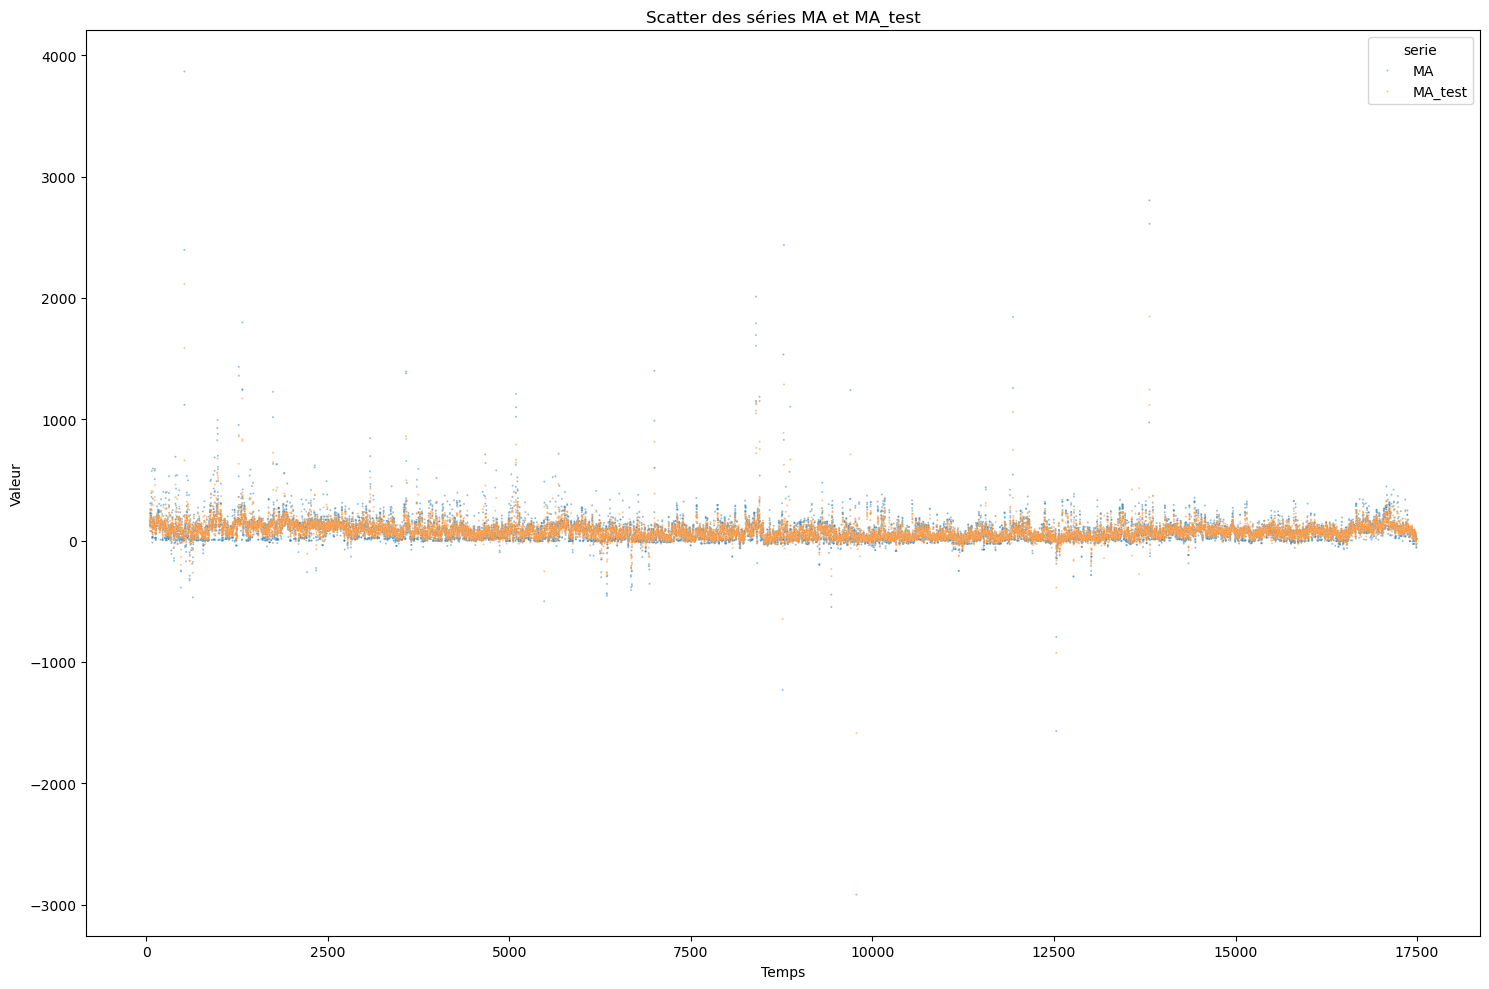

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Données longues (deux séries sur l'axe Y)
df = Y[['MA', 'MA_test']].dropna().reset_index().rename(columns={'index': 't'})
df_long = df.melt(id_vars='t', value_vars=['MA', 'MA_test'],
                  var_name='serie', value_name='val')

plt.figure(figsize=(15, 10))
sns.scatterplot(data=df_long, x='t', y='val', hue='serie', s=2, alpha=0.5)
plt.xlabel('Temps')
plt.ylabel('Valeur')
plt.title('Scatter des séries MA et MA_test')
plt.tight_layout()
plt.show()

Out of sample

In [21]:
data[source2].iloc[0:24]

,MA,SPOT,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso
0,1.050858,-0.942618,-0.038028,-0.089212,-0.283558,-0.004085,-1.302513,-0.280012,-0.484189,0.136284,-0.634085,-1.608579,2.678594,0.396101
1,1.134432,-0.942618,-0.038028,-0.089212,-0.283558,-0.004085,-1.302513,-0.280012,-0.484189,0.136284,-0.634085,-1.608579,2.678594,0.415401
2,-0.499639,-1.025522,-0.038028,-0.074077,-0.277371,0.230530,-1.322680,-0.325767,-0.693506,-0.138940,-0.697342,-1.665263,2.613266,-0.144311
3,-0.204629,-1.025522,-0.038028,-0.074077,-0.277371,0.230530,-1.322680,-0.325767,-0.693506,-0.138940,-0.697342,-1.665263,2.613266,-0.057459
4,-0.615178,-1.420607,-0.038028,-0.100815,-0.277371,0.222440,-1.096100,-0.200150,-0.984866,-0.158964,-0.697342,-1.608579,2.513925,0.106594
5,-0.301865,-1.420607,-0.038028,-0.100815,-0.277371,0.222440,-1.096100,-0.200150,-0.984866,-0.158964,-0.697342,-1.608579,2.513925,0.164496
6,-1.284129,-1.421591,-0.038028,-0.105355,-0.283558,0.222440,-1.276415,-0.235090,-1.057443,-0.194197,-0.697342,-1.608579,2.251266,0.318899
7,-0.106412,-1.421591,-0.038028,-0.105355,-0.283558,0.222440,-1.276415,-0.235090,-1.057443,-0.194197,-0.697342,-1.608579,2.251266,0.415401
8,-0.130609,-1.421837,-0.038028,-0.111914,-0.283558,0.230530,-1.263366,-0.245904,-1.202597,-0.198818,-0.697342,-1.594409,0.959565,0.289948
9,0.481822,-1.421837,-0.038028,-0.111914,-0.283558,0.230530,-1.263366,-0.245904,-1.202597,-0.198818,-0.697342,-1.594409,0.959565,0.357500


In [22]:
STEP=[24,48,100,150,200,250,300,350,400,450,500,600,700,800,900,1000,2000,5000]
R=[]
MAE=[]
MSE=[]
for Step in STEP:
    n=len(data)
    m=n-Step
    modelout=VAR(data[source2].iloc[0:m],data[['Heure_sin','Heure_cos']].iloc[0:m])
    res = modelout.fit(49)
    hist = data[source2].iloc[m-res.k_ar:m].copy()
    ma_fc = []

    for t in range(Step):
        yhat = res.forecast(y=hist.to_numpy(), steps=1,exog_future=data.loc[m+t:m+t, ['Heure_sin','Heure_cos']].to_numpy() )[0]
        yhat = pd.Series(yhat, index=source2)
        # Imposer les variables connues sauf 'MA'
        known = [c for c in source2 if c != 'MA']
        yhat.loc[known] = data.loc[m+t, known].values
        hist = pd.concat([hist, yhat.to_frame().T]).iloc[-res.k_ar:]
        ma_fc.append(yhat['MA'])

    ma_fc = pd.DataFrame(ma_fc, index=data.index[m:m+Step], columns=['MA_fc'])
    ma_fc_inv= Yscaler.inverse_transform(ma_fc, copy=None)
    ma_fc_inv_l=[x[0] for x in ma_fc_inv]
    n=len(Y)
    ma_true=list(Y['MA'].iloc[n-Step:n])

    mae=mean_absolute_error(ma_true,ma_fc_inv)
    mse=mean_squared_error(ma_true,ma_fc_inv)
    r2=r2_score(ma_true,ma_fc_inv_l,)
    R.append(r2)
    MAE.append(mae)
    MSE.append(mse)
RESULT=pd.DataFrame({'STEP':STEP,'R2':R,'MAE':MAE,'MSE':MSE})

In [23]:
RESULT

,STEP,R2,MAE,MSE
0,24,-0.844229,37.573531,1887.029591
1,48,-0.631891,37.316498,1942.714043
2,100,-0.424058,31.792441,1902.644892
3,150,-0.136906,40.006823,2583.999666
4,200,-0.044714,39.526598,2718.897868
5,250,-0.032201,37.252708,2507.629435
6,300,0.023686,39.422446,2913.680039
7,350,0.118075,40.939387,3499.928876
8,400,0.190016,44.139170,4063.233817
9,450,0.220814,48.223843,4829.716521


In [111]:
STEP=[48]
R=[]
MAE=[]
MSE=[]
Nn=[10000,10500,11000,11500,12000,12500,13000,13500,14000,14500,15000]
Nn_=[]
STEP_=[]

for Step in STEP:
    res = modelout.fit(49)
    for n in range(10000,17000,10):
        m=n-Step
        modelout=VAR(data[source2].iloc[0:m],data[['Heure_sin','Heure_cos']].iloc[0:m])
        hist = data[source2].iloc[m-res.k_ar:m].copy()
        ma_fc = []

        for t in range(Step):
            yhat = res.forecast(y=hist.to_numpy(), steps=1,exog_future=data.loc[m+t:m+t, ['Heure_sin','Heure_cos']].to_numpy() )[0]
            yhat = pd.Series(yhat, index=source2)
            # Imposer les variables connues sauf 'MA'
            known = [c for c in source2 if c != 'MA']
            yhat.loc[known] = data.loc[m+t, known].values
            hist = pd.concat([hist, yhat.to_frame().T]).iloc[-res.k_ar:]
            ma_fc.append(yhat['MA'])

        ma_fc = pd.DataFrame(ma_fc, index=data.index[m:m+Step], columns=['MA_fc'])
        ma_fc_inv= Yscaler.inverse_transform(ma_fc, copy=None)
        ma_fc_inv_l=[x[0] for x in ma_fc_inv]
        ma_true=list(Y['MA'].iloc[n-Step:n])
        naive=list(Y['MA'].iloc[n-Step-Step:n-Step])

        mae=mean_absolute_error(ma_true,ma_fc_inv)
        mse=mean_squared_error(ma_true,ma_fc_inv)
        r2=r2_score(ma_true,ma_fc_inv_l,)
        R.append(r2)
        MAE.append(mae)
        MSE.append(mse)
        Nn_.append(n)
        STEP_.append(Step)
RESULT=pd.DataFrame({'N':Nn_,'STEP':STEP_,'R2':R,'MAE':MAE,'MSE':MSE})

In [112]:
RESULT['MAE'].mean()

51.36609956187706

In [113]:
ma_fc_inv_l

[206.02340058635394,
 146.62176063713986,
 107.4849510797534,
 86.7853431894324,
 70.25726245128124,
 110.33739184933165,
 120.533969541072,
 122.84280924954429,
 100.3805666435245,
 102.55910655306315,
 115.87189499488679,
 135.55733798182928,
 96.51669961250329,
 99.38525195380565,
 95.41545239313393,
 115.13476282978814,
 148.70975321954234,
 148.94002609249588,
 186.16806970834617,
 145.1936875377894,
 145.62920405625323,
 113.86255534784459,
 117.71225415106576,
 121.31159476638412,
 118.09202119802413,
 127.95792149206795,
 127.17077958013276,
 136.1919406831154,
 137.05516437982627,
 106.21558310609495,
 84.74325542919338,
 72.86999734762468,
 111.67973562755068,
 89.55753387504095,
 97.78791590761423,
 87.91980347398425,
 67.85172351869227,
 58.45202039558001,
 117.07414155781996,
 126.49268211390583,
 113.50523840577483,
 93.56617859015637,
 96.81772566214482,
 97.20708306335989,
 117.14121121033676,
 119.61871049993692,
 130.36890623598006,
 107.11297823554034]

In [114]:
naive

[244.16,
 234.83,
 196.3,
 180.65,
 162.07,
 146.56,
 174.8,
 109.39,
 229.22,
 87.99,
 71.17,
 148.02,
 49.11,
 87.05,
 92.27,
 99.03,
 91.28,
 88.6,
 133.33,
 164.36,
 85.6,
 112.01,
 87.05,
 77.53,
 7.54,
 85.03,
 102.78,
 72.64,
 55.09,
 129.15,
 108.7,
 77.29,
 109.49,
 69.9,
 140.52,
 230.12,
 220.12,
 203.93,
 201.77,
 156.47,
 156.86,
 218.26,
 99.39,
 115.67,
 110.27,
 104.87,
 110.45,
 115.48]

In [120]:
ma_true

[117.19,
 117.99,
 154.75,
 120.09,
 119.82,
 123.54,
 164.94,
 113.55,
 123.8,
 142.36,
 134.2,
 136.46,
 141.31,
 147.56,
 134.17,
 62.67,
 39.86,
 65.1,
 66.1,
 92.6,
 101.11,
 84.78,
 71.52,
 77.82,
 78.57,
 65.1,
 85.43,
 105.69,
 113.77,
 114.96,
 106.13,
 96.82,
 176.94,
 104.59,
 176.23,
 38.81,
 54.14,
 155.31,
 154.6,
 176.86,
 174.78,
 205.05,
 95.1,
 85.67,
 70.9,
 134.99,
 192.93,
 251.72]

In [121]:
Graph=pd.DataFrame({'MA_true':ma_true,'MA_naive':naive,'MA_VAR':ma_fc_inv_l})

In [134]:
Graph["Naive-True"]=Graph['MA_naive']-Graph['MA_true']
Graph["VAR-TRUE"]=Graph['MA_naive']-Graph['MA_VAR']

Text(0.5, 0, 'heure+')

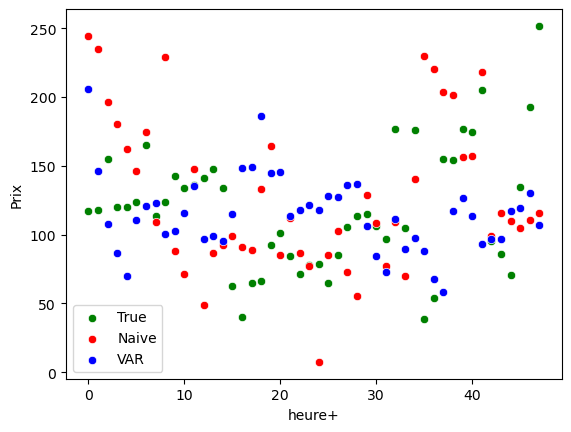

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=Graph.index, y=Graph['MA_true'],color='green',label='True')
sns.scatterplot(x=Graph.index, y=Graph['MA_naive'],color='red',label='Naive')
sns.scatterplot(x=Graph.index, y=Graph['MA_VAR'],color='blue',label='VAR')
plt.ylabel('Prix')
plt.xlabel('heure+')





Text(0.5, 0, 'heure+')

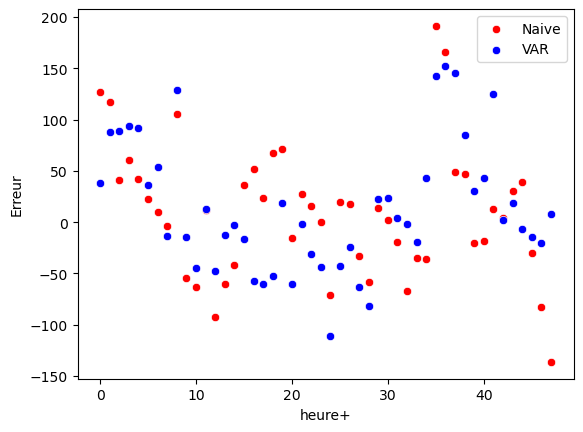

In [152]:
import seaborn as sns
sns.scatterplot(x=Graph.index, y=Graph['Naive-True'],color='red',label='Naive')
sns.scatterplot(x=Graph.index, y=Graph['VAR-TRUE'],color='blue',label='VAR')
plt.ylabel('Erreur')
plt.xlabel('heure+')



<Axes: xlabel='Count', ylabel='Naive-True'>

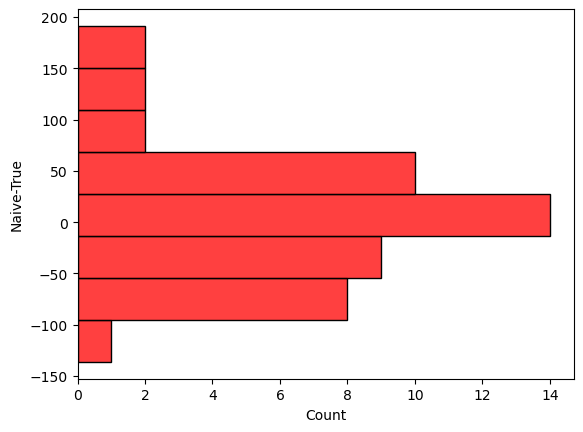

In [147]:
import seaborn as sns
sns.histplot(y=Graph['Naive-True'],color='red',label='Naive')

# sns.histplot(x=Graph.index, y=Graph['VAR-TRUE'],color='blue',label='VAR')




<Axes: xlabel='Count', ylabel='VAR-TRUE'>

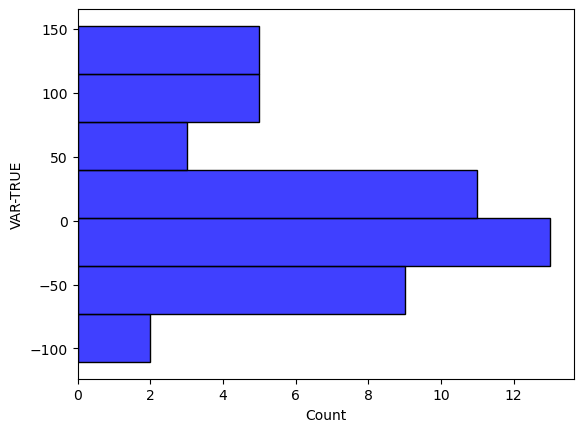

In [153]:
sns.histplot(y=Graph['VAR-TRUE'],color='blue',label='Naive')


In [130]:
mean_absolute_error(Graph['MA_true'],Graph['MA_naive'])

49.25645833333334

In [131]:
mean_absolute_error(Graph['MA_true'],Graph['MA_VAR'])

46.30969055985003

### Comparaison

Objectif: Utiliser modèle sur différentes bases

In [115]:
Y

,MA,MA_diff,MA_test
49,166.75,-14.10,180.464109
50,154.35,-12.40,136.295630
51,123.95,-30.40,130.149820
52,122.82,-1.13,78.214461
53,121.89,-0.93,129.452504
...,...,...,...
17490,-57.88,-20.60,5.436431
17491,16.37,74.25,-30.426254
17492,16.37,0.00,12.744057
17493,16.37,0.00,60.882787


In [116]:
MAE_=[]
Nn=[10000,10500,11000,11500,12000,12500,13000,13500,14000,14500,15000]

Nn_=[]
STEP_=[]
for Step in STEP:
    for n in range(10000,17000,50):
        N=n-Step
        mae=mean_absolute_error(Y['MA'].iloc[int(N):],Y['MA'].iloc[int(N):].shift(48).fillna(0))
        MAE_.append(mae)
        Nn_.append(n)
        STEP_.append(Step)

RESULT_=pd.DataFrame({'Nn_':Nn_,'Step':STEP_,'mae_NAIF':MAE_})

In [117]:
RESULT_

,Nn_,Step,mae_NAIF
0,10000,48,57.213196
1,10050,48,57.289518
2,10100,48,57.395714
3,10150,48,56.921679
4,10200,48,56.328932
...,...,...,...
135,16750,48,64.785793
136,16800,48,64.974481
137,16850,48,63.389705
138,16900,48,67.127828


In [118]:
RESULT_['mae_NAIF'].mean()

55.272102292828585